In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


In [2]:
# Load German Credit dataset
credit = fetch_openml(name='credit-g', version=1, as_frame=True)

df = credit.data
df['target'] = credit.target

print("Shape:", df.shape)
print("\nTarget values:", df['target'].unique())
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 21)

Target values: ['good', 'bad']
Categories (2, str): ['bad', 'good']

First 5 rows:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [3]:
# Basic dataset info
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Distribution ===")
print(df['target'].value_counts())
print("\nPercentage:")
print(df['target'].value_counts(normalize=True) * 100)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing        

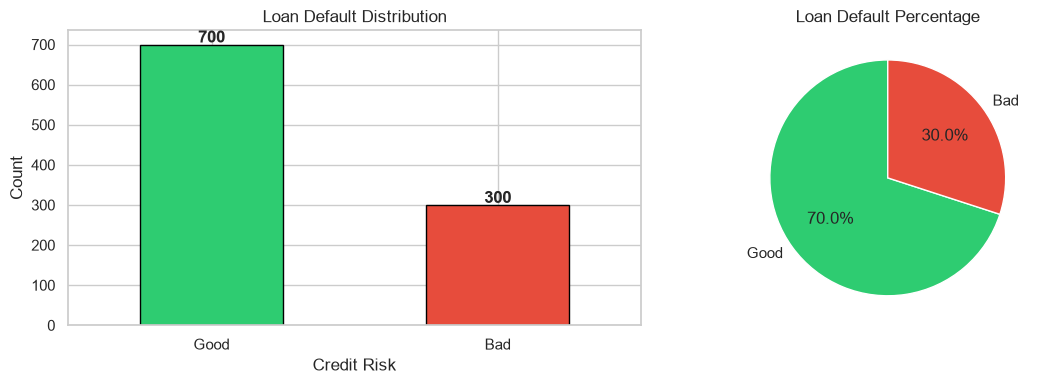

In [8]:
# Target distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['target'].value_counts().plot(kind='bar', ax=axes[0], 
                                  color=['#2ecc71', '#e74c3c'], 
                                  edgecolor='black')
axes[0].set_title('Loan Default Distribution')
axes[0].set_xlabel('Credit Risk')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Good', 'Bad'], rotation=0)


for i, v in enumerate(df['target'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
df['target'].value_counts().plot(kind='pie', ax=axes[1],
                                  colors=['#2ecc71', '#e74c3c'],
                                  autopct='%1.1f%%',
                                  labels=['Good', 'Bad'],
                                  startangle=90)
axes[1].set_title('Loan Default Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

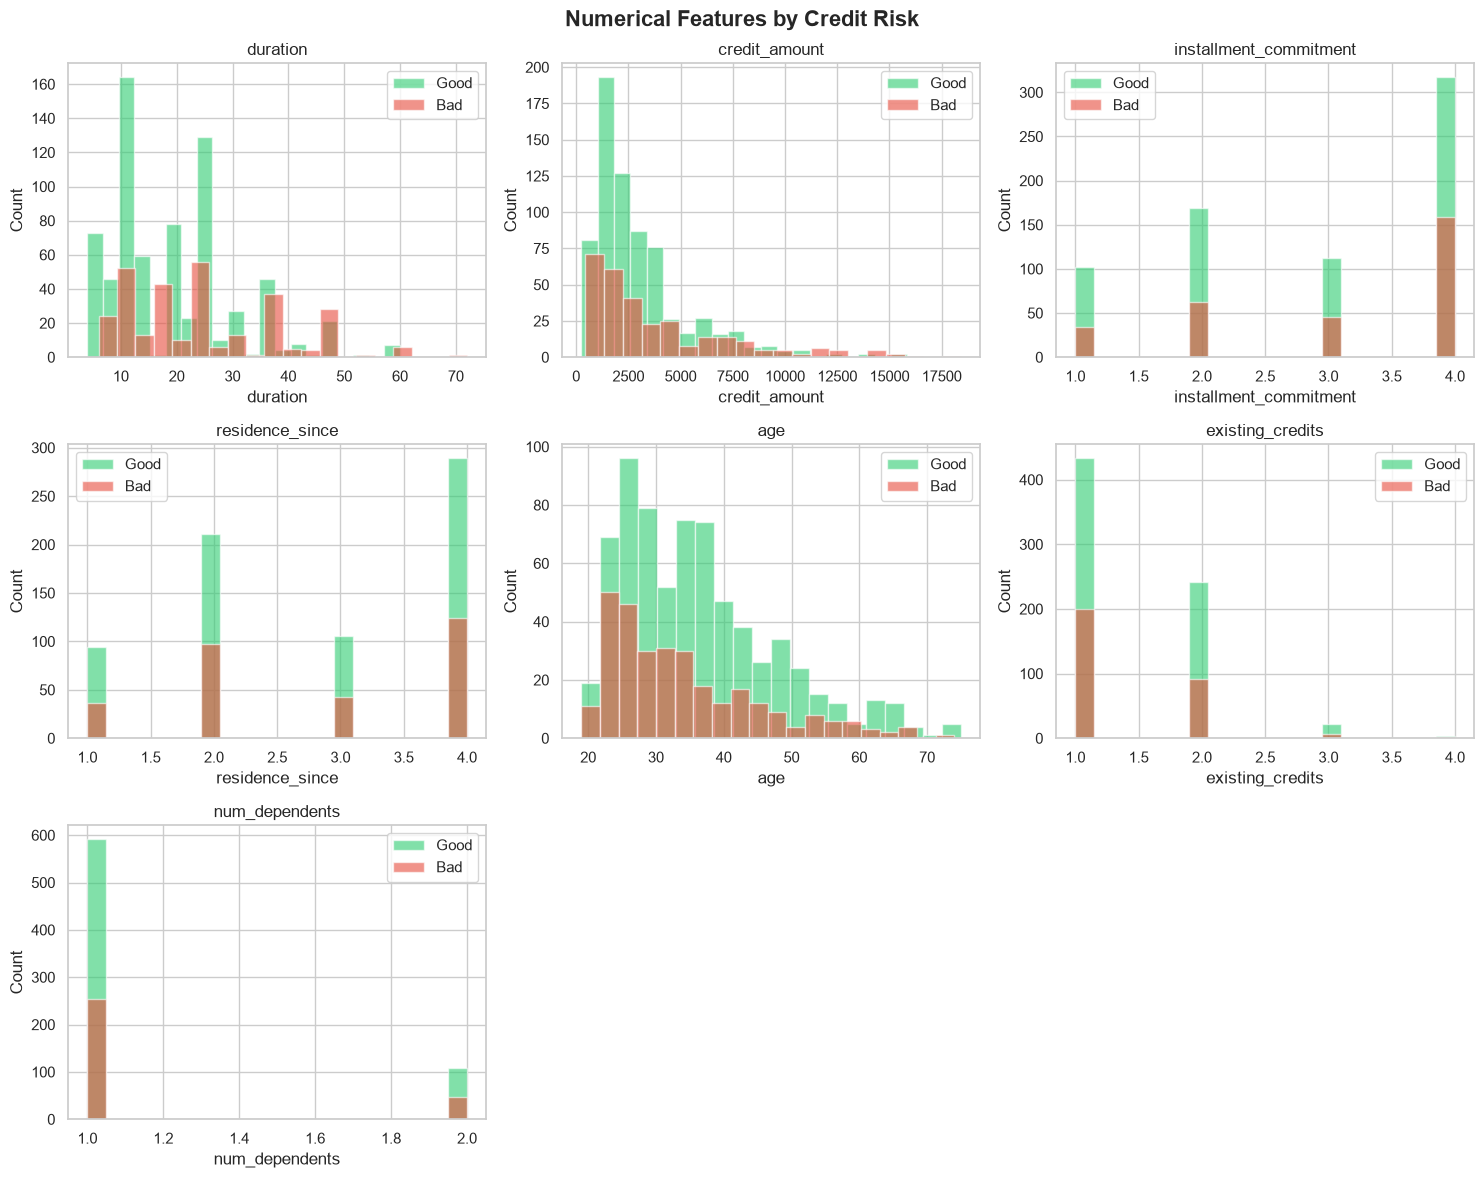

In [9]:
# Numerical features distribution
numerical_cols = ['duration', 'credit_amount', 'installment_commitment', 
                  'residence_since', 'age', 'existing_credits', 'num_dependents']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[df['target']=='good'][col], alpha=0.6, 
                 color='#2ecc71', label='Good', bins=20)
    axes[i].hist(df[df['target']=='bad'][col], alpha=0.6, 
                 color='#e74c3c', label='Bad', bins=20)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

# Hide empty subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Numerical Features by Credit Risk', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

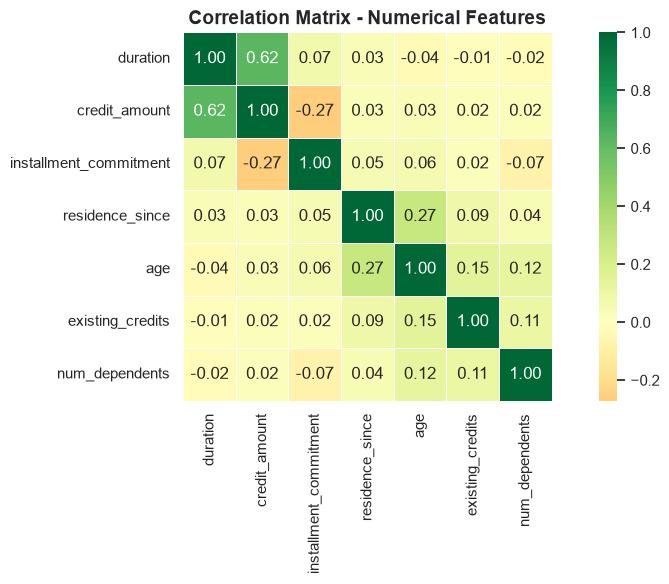

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 6))

numerical_df = df[numerical_cols].copy()
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

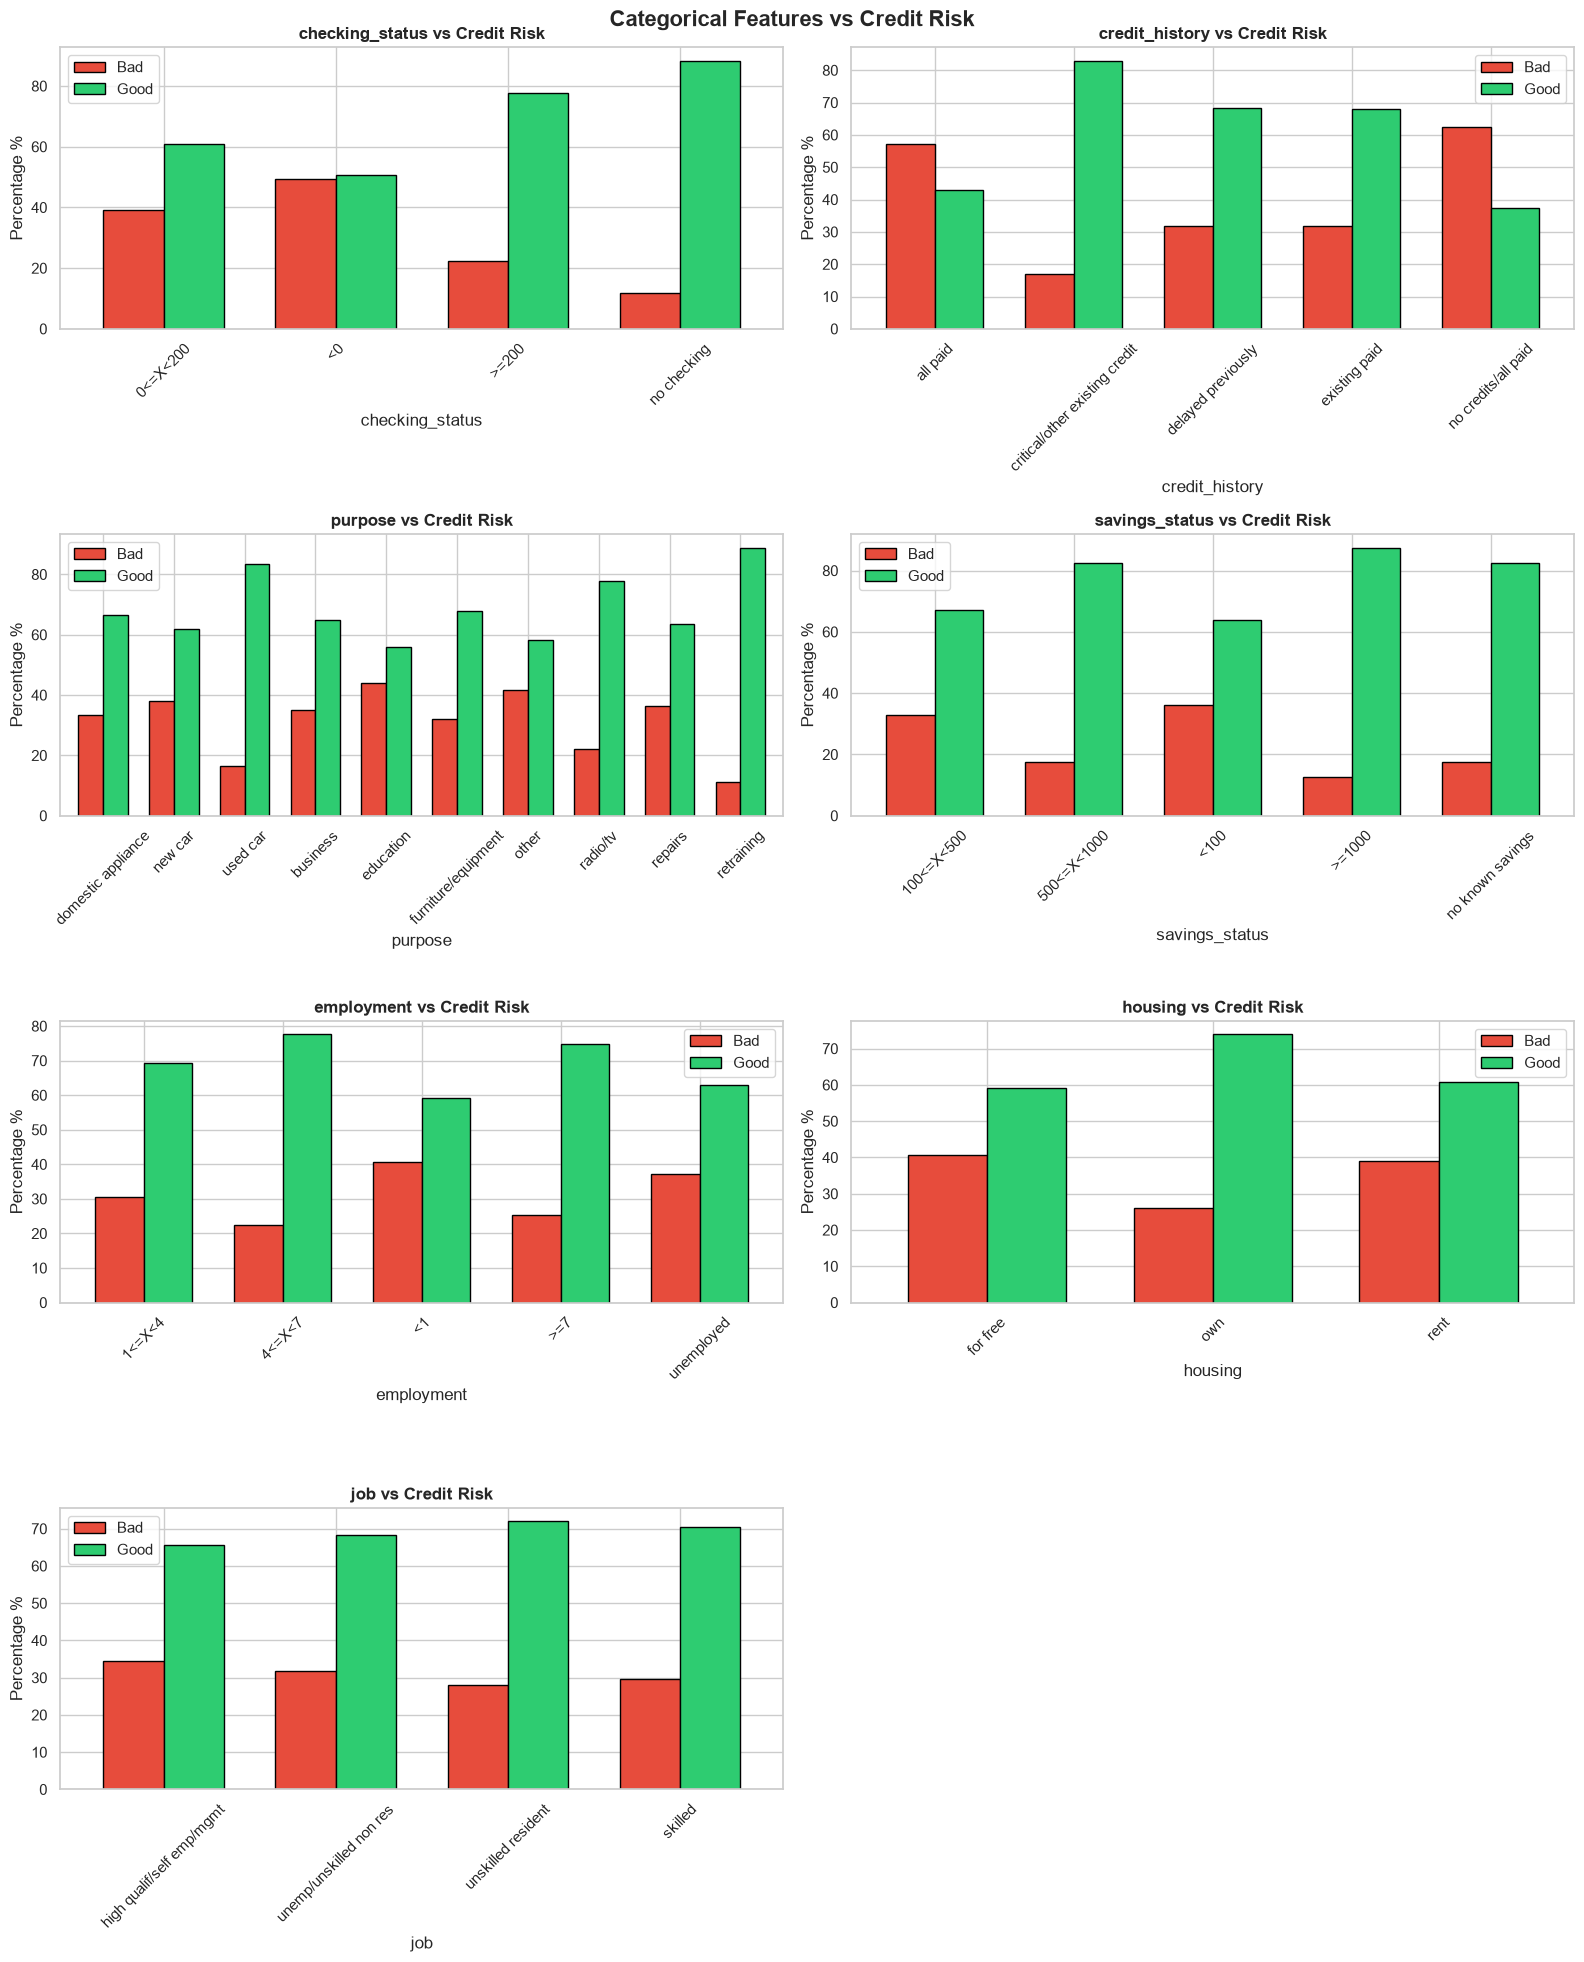

In [11]:
# Categorical features vs target
categorical_cols = ['checking_status', 'credit_history', 'purpose', 
                    'savings_status', 'employment', 'housing', 'job']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate percentage of bad loans per category
    cross_tab = pd.crosstab(df[col], df['target'], normalize='index') * 100
    
    cross_tab.plot(kind='bar', ax=axes[i], 
                   color=['#e74c3c', '#2ecc71'],
                   edgecolor='black',
                   width=0.7)
    
    axes[i].set_title(f'{col} vs Credit Risk', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage %')
    axes[i].legend(['Bad', 'Good'])
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)

plt.suptitle('Categorical Features vs Credit Risk', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

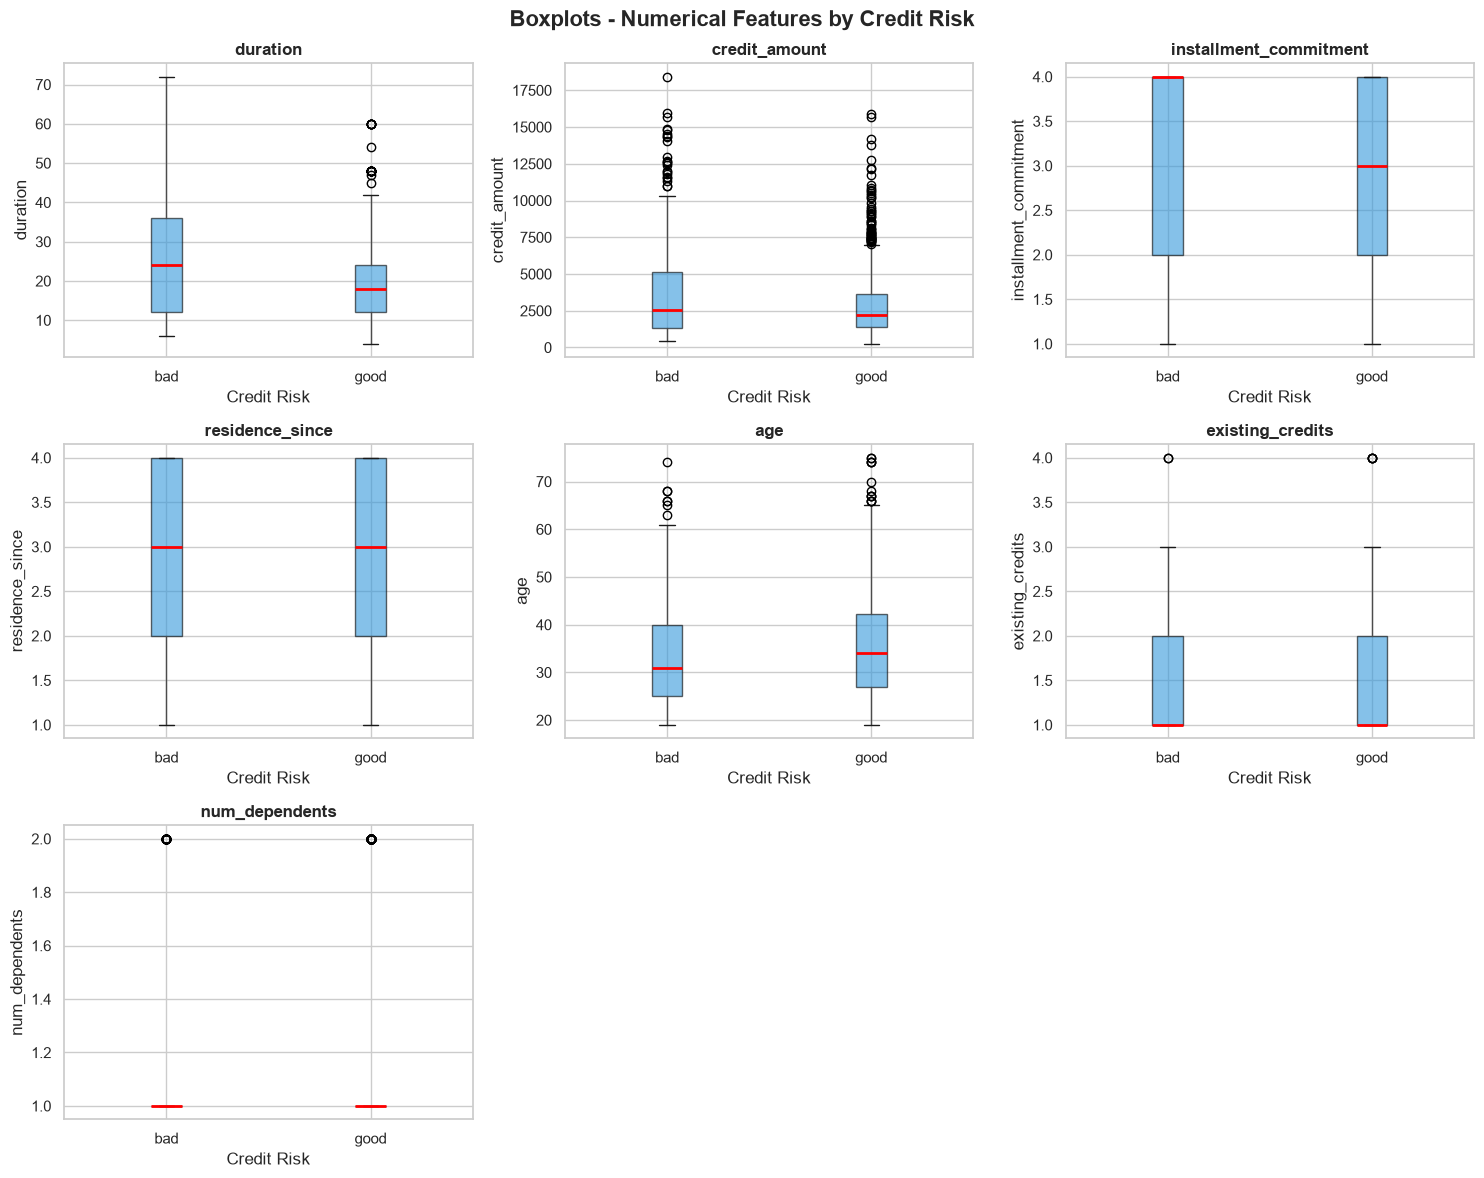

In [12]:
# Boxplots for numerical features vs target
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='target', ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Credit Risk')
    axes[i].set_ylabel(col)

for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Boxplots - Numerical Features by Credit Risk', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()